# Bibliotecas

In [56]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


# Carregando Dados, tratamento e análise de dados

In [57]:
df = pd.read_csv('../dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [58]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [59]:
df.shape

(7043, 21)

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [61]:
espacos_em_branco = (df == " ").sum()
colunas_com_problema = espacos_em_branco[espacos_em_branco > 0]
espacos_em_branco


customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [62]:
# Tratamento valores ausentes (Missing Values)
df['TotalCharges'] = df['TotalCharges'].replace(" ", np.nan)
df['TotalCharges'] = df['TotalCharges'].astype(float)
median_total_charges = df['TotalCharges'].median()
df['TotalCharges'] = df['TotalCharges'].fillna(median_total_charges)

Diagnóstico de outliers


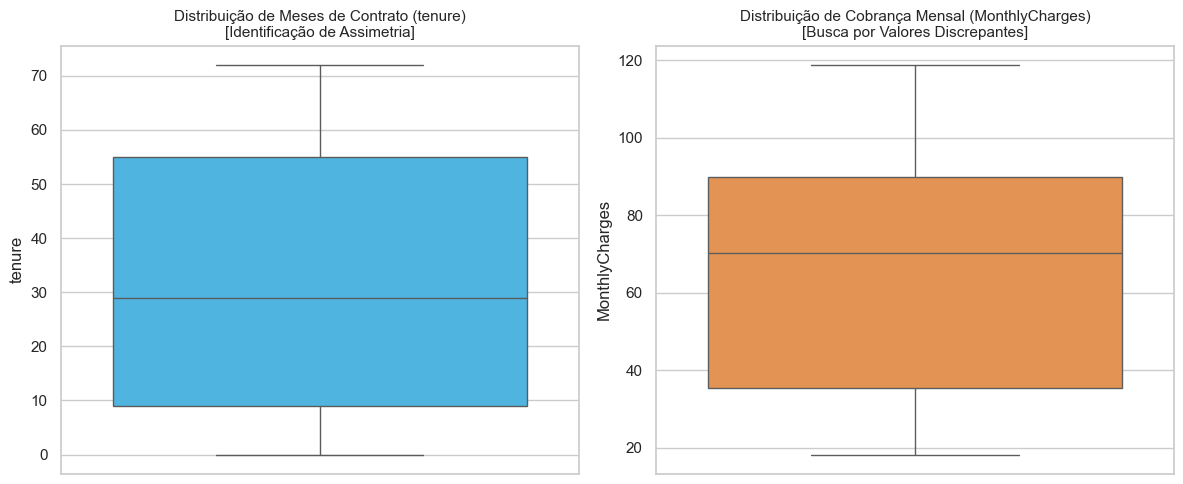

In [63]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].replace(" ", None))

plt.figure(figsize=(12, 5))
sns.set_theme(style="whitegrid")

#Tenure e MonthlyCharges
plt.subplot(1, 2, 1)
sns.boxplot(data=df, y='tenure', color='#38bdf8')
plt.title('Distribuição de Meses de Contrato (tenure)\n[Identificação de Assimetria]', fontsize=11)

plt.subplot(1, 2, 2)
sns.boxplot(data=df, y='MonthlyCharges', color='#fb923c')
plt.title('Distribuição de Cobrança Mensal (MonthlyCharges)\n[Busca por Valores Discrepantes]', fontsize=11)

plt.tight_layout()
print("Diagnóstico de outliers")
plt.show()

In [64]:
#Tratamento de Outliers

for col in ['tenure', 'MonthlyCharges', 'TotalCharges']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    # Capando os outliers nos limites estatísticos para não perder linhas do dataset
    df[col] = np.where(df[col] > limite_superior, limite_superior, df[col])
    df[col] = np.where(df[col] < limite_inferior, limite_inferior, df[col])

In [65]:
# Remoção de identificador irrelevante para a modelagem estatística
df.drop(columns=['customerID'], inplace=True)

In [66]:
# Feature Engineering / Discretização para o Núcleo Bayesiano
df['TenureCluster'] = pd.cut(df['tenure'], bins=[0, 12, 36, 100], labels=['Curto Prazo', 'Medio Prazo', 'Longo Prazo'])
df['MonthlyChargesCluster'] = pd.cut(df['MonthlyCharges'], bins=[0, 35, 75, 150], labels=['Baixo Gasto', 'Medio Gasto', 'Alto Gasto'])

# Análise Exploratória

In [67]:
#artefatos
os.makedirs('assets', exist_ok=True)

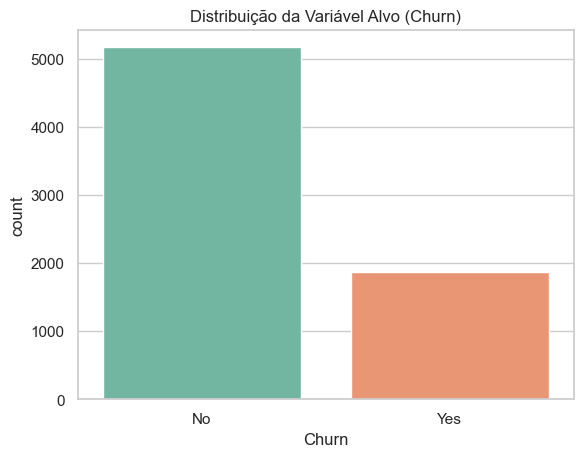

In [68]:
# Distribuição da Variável Alvo
plt.figure()
sns.countplot(data=df, x='Churn', hue='Churn', palette='Set2', legend=False)
plt.title('Distribuição da Variável Alvo (Churn)')
plt.show()

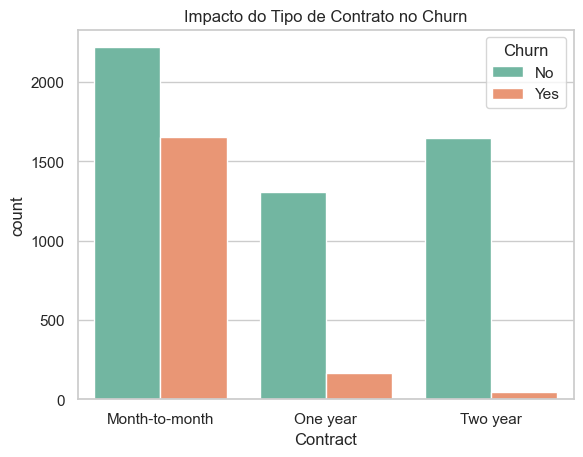

In [69]:
# Gráfico 2: Tipo de Contrato vs Churn
plt.figure()
sns.countplot(data=df, x='Contract', hue='Churn', palette='Set2')
plt.title('Impacto do Tipo de Contrato no Churn')
plt.show()

# Núcleo Probabilístico: Teorema de Bayes

In [ ]:
#Treinamento da Implementação Teórica do Teorema de Bayes
class ImplementacaoBayesManual:

    # Modelagem Matemática do Teorema de Bayes P(C|X) = (P(X|C) * P(C)) / P(X)

    def __init__(self):
        self.p_prior = {}
        self.p_conditional = {}
        self.classes = None
        
    def treinar(self, X_cat, y):
        self.classes = y.unique()
        n_total = len(y)
        
        for c in self.classes:
            self.p_prior[c] = len(y[y == c]) / n_total
            
        X_cat_df = X_cat.copy()
        X_cat_df['target'] = y
        
        for col in X_cat.columns:
            self.p_conditional[col] = {}
            for c in self.classes:
                sub_df = X_cat_df[X_cat_df['target'] == c]
                counts = sub_df[col].value_counts()
                # Laplace para evitar probabilidade zero multiplicativa
                total_classe = len(sub_df)
                voca_tamanho = X_cat[col].nunique()
                self.p_conditional[col][c] = {val: (count + 1) / (total_classe + voca_tamanho) for val, count in counts.items()}

    def predizer_probabilidade(self, instancia_dict):
        posteriors = {}
        soma_evidencias = 0
        
        for c in self.classes:
            prior = self.p_prior[c]
            verossimilhanca = 1.0
            
            for col, val in instancia_dict.items():
                if col in self.p_conditional and val in self.p_conditional[col][c]:
                    verossimilhanca *= self.p_conditional[col][c][val]
                else:
                    verossimilhanca *= (1 / (len(self.p_prior) + 10))
            
            posteriors[c] = verossimilhanca * prior
            soma_evidencias += posteriors[c]
            
        for c in posteriors:
            if soma_evidencias > 0:
                posteriors[c] /= soma_evidencias
            else:
                posteriors[c] = self.p_prior[c]
                
        return posteriors

In [71]:
# Features categóricas estruturadas --> originais + discretizadas 
features_bayes = ['Contract', 'PaperlessBilling', 'TenureCluster', 'MonthlyChargesCluster']
X_bayes = df[features_bayes].astype(str)
y_bayes = df['Churn']

bayes_manual = ImplementacaoBayesManual()
bayes_manual.treinar(X_bayes, y_bayes) 
os.makedirs('modelos', exist_ok=True)
joblib.dump(bayes_manual, 'modelos/bayes_manual.pkl')

['modelos/bayes_manual.pkl']

# Algoritmos de Classificação 

In [72]:
# Treinando os modelos de Machine Learning e Coletando Métricas 

df_ml = df.copy()
# Garantindo que as colunas auxiliares criadas para o Bayes não entrem no ML avançado
df_ml.drop(columns=['TenureCluster', 'MonthlyChargesCluster'], errors='ignore', inplace=True)

label_encoders = {}
for col in df_ml.select_dtypes(include=['object', 'category']).columns:
    if col != 'Churn':
        le = LabelEncoder()
        df_ml[col] = le.fit_transform(df_ml[col].astype(str))
        label_encoders[col] = le

# Encoding estrito da variável alvo
le_target = LabelEncoder()
df_ml['Churn'] = le_target.fit_transform(df_ml['Churn'])
label_encoders['Churn'] = le_target

X = df_ml.drop(columns=['Churn'])
y = df_ml['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modelo 1: Regressão Logística
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

# Modelo 2: Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

In [73]:
# Exibição de Métricas
print("="*40)
print(f"Regressão Logística -> Acurácia: {accuracy_score(y_test, y_pred_lr):.4f} | F1-Score: {f1_score(y_test, y_pred_lr):.4f} | Precisão: {precision_score(y_test, y_pred_lr):.4f} | Recall: {recall_score(y_test, y_pred_lr):.4f}")
print(f"Random Forest       -> Acurácia: {accuracy_score(y_test, y_pred_rf):.4f} | F1-Score: {f1_score(y_test, y_pred_rf):.4f} | Precisão: {precision_score(y_test, y_pred_rf):.4f} | Recall: {recall_score(y_test, y_pred_rf):.4f}")
print("="*40 + "\n")


Regressão Logística -> Acurácia: 0.7991 | F1-Score: 0.5916 | Precisão: 0.6426 | Recall: 0.5481
Random Forest       -> Acurácia: 0.7921 | F1-Score: 0.5620 | Precisão: 0.6373 | Recall: 0.5027



In [74]:
# Artefatos 
joblib.dump(scaler, 'modelos/scaler.pkl')
joblib.dump(lr_model, 'modelos/regressao_logistica.pkl')
joblib.dump(rf_model, 'modelos/random_forest.pkl')
joblib.dump(label_encoders, 'modelos/encoders.pkl')
joblib.dump(X_test, 'modelos/X_test.pkl')
joblib.dump(y_test, 'modelos/y_test.pkl')

['modelos/y_test.pkl']